# 港股高红利低波动策略 (High Dividend Low Volatility Strategy)

## 策略简介
本策略依托于 **HSCI (恒生综合指数)** 股票池，旨在筛选出具备极强分红持续性、良好流动性，且具有较低市场波动率的港股优质标的。通过平衡绝对分红金额与股票波动风险，策略致力于在长周期回测中获取稳定的超额收益与更优的风险回报比（Sharpe Ratio）。

## 选股逻辑
在每个调仓日，我们将对 HSCI 股票池中的标的执行以下重重筛选与排序：

1. **基本面与数据完整性**：
   - 剔除上市时间较短或缺失核心月频因子（如近三年股息率、近一年波动率、近三月成交额等）的数据。
2. **极严格的分红持续性考察**：
   - 提取标的过去 36 个月的股息率。
   - **剔除**：在过去 36 个月中，出现过任意一个月没有股息或股息率为空的股票（确保标的拥有连年不间断分红的历史底蕴）。
3. **流动性与规模双重过滤 (Top 70%)**：
   - 根据当月市场截面，动态计算该期个股的**近 3 个月日均成交额**和**总市值**。
   - **剔除**：成交额位列倒数 30% 或者市值位列倒数 30% 的尾部股票，以此避开流动性枯竭的仙股与微盘股。（即只保留成交量和市值均在全市场前 70% 的股票）。
4. **极端值清洗**：
   - 将得分排在全市场前 `0.1%` 的极端异常高股息率样本剔除，防止“数据陷阱”（如股价暴跌导致的伪高息）。
5. **核心排序因子 (DPS)**：
   - 计算 3 年平均每股股利 (3-Year Avg DPS)： $\frac{1}{n} \sum (P_i \times DY_i) / CurrentPrice$。
   - 取上述股息评分排名前 `35%` 的标的进入最终备选池。
6. **低波动精选**：
   - 在进入精选池的标的中，选取“近一年日收益率年化波动率 (`volatility`)” **最低的 15 只**（受代码 `n_final = min(20, len(pool))` 控制）个股作为本期最终持仓。

## 回测及资产配置
- **起始时间**：默认为 2012-01 至今
- **配置与调仓**：定期调仓（如季度频率 `REBALANCE_FREQ = 3`）。
- **权重方案**：
    - **等权配置 (Equal Weight)**：所有选出个股等比例配置。
    - **带上限的市值加权 (Cap Weight)**：按个股市值比例配置权重，但单一个股最高权重不得超过 `MAX_WEIGHT_LIMIT` (例如 10%)。若有超限部分，则按市值比例平摊给其他未达到上限的持仓。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# 1. 加载数据
print("Loading data...")
# ① 股息率 (月频)
dy = pd.read_hdf('data/hk_dividendyield.h5')
if isinstance(dy, pd.DataFrame):
    dy = dy.iloc[:, 0] # 转换为Series
dy = dy.dropna().reset_index()
if dy.shape[1] == 3:
    dy.columns = ['date', 'sid', 'dy']
elif dy.shape[1] == 2:
    dy.columns = ['date', 'dy'] # fallback

dy['date'] = pd.to_datetime(dy['date'])

# --- 后端回测计算 ---
print("Loading data for Backtest...")

# 1. 加载用于计算收益率的复权价及用于计算市值的股本数据
price_cols = pd.read_csv('data/hk_price.csv', usecols=['date', 'sid', 'close', 'AdjClose'])
price_cols['date'] = pd.to_datetime(price_cols['date'])
price_cols['date_m'] = price_cols['date'].dt.to_period('M')

# 计算每月的收益率（基于当月最后一天到下月最后一天的复权收盘价）
monthly_price = price_cols.sort_values('date').groupby(['date_m', 'sid']).last().reset_index()
monthly_price_pivot = monthly_price.pivot(index='date_m', columns='sid', values='AdjClose')
# 计算各股票的下月收益率，以日期t对齐
# 资产在t月末的权重将乘以 t+1 月的收益率
monthly_ret = monthly_price_pivot.pct_change(fill_method=None).shift(-1) 

# 加载股本数据
with pd.HDFStore('data/hk_shares.h5') as store:
    shares = store.get(store.keys()[0]).reset_index()

shares['sid'] = shares['order_book_id'].str[1:5] + '.HK'
shares['date_m'] = pd.to_datetime(shares['date']).dt.to_period('M')
shares_monthly = shares.sort_values('date').groupby(['date_m', 'sid']).last().reset_index()

# 合并价格和股本数据以计算市值
mcap_df = pd.merge(monthly_price[['date_m', 'sid', 'close']], 
                   shares_monthly[['date_m', 'sid', 'total']], 
                   on=['date_m', 'sid'], how='inner')
mcap_df['mcap'] = mcap_df['close'] * mcap_df['total']
mcap_pivot = mcap_df.pivot(index='date_m', columns='sid', values='mcap')

# ② 价格数据 (日频) - 用于计算波动率和流动性
# 取包含成交额(amount)的数据
price = pd.read_csv('data/hk_price.csv', usecols=['date', 'sid', 'close', 'amount'])
price['date'] = pd.to_datetime(price['date'])

# ③ 股票池 (HSCI)
hsci = pd.read_csv('data/HSCI.csv')
hsci['date'] = pd.to_datetime(hsci['date'])
hsci['is_hsci'] = 1
# 为了处理如果HSCI只有一条当月数据对应整月的情况，也可以直接去重
hsci = hsci.drop_duplicates(subset=['date', 'sid'])

# 2. 计算红利稳定度 (近3年=36个月的回归，剔除空值)
print("Calculating Dividend Stability...")
dy_pivot = dy.pivot(index='date', columns='sid', values='dy')
dy_pivot = dy_pivot.sort_index()

def calc_stability_slope(x):
    x = x[~np.isnan(x)]
    if len(x) < 12:
        return np.nan
    t = np.arange(len(x))
    slope, intercept, r_value, p_value, std_err = stats.linregress(t, x)
    return slope

# 滚动36个月计算每个时点的股息率趋势斜率
dy_trend = dy_pivot.rolling(window=36, min_periods=12).apply(calc_stability_slope, raw=True)
dy_trend_stacked = dy_trend.stack().reset_index()
dy_trend_stacked.columns = ['date', 'sid', 'dy_trend']

# 3. 计算低波动率因子 (采用近1年=252天的日收益率波动率)
print("Calculating Volatility (Low Vol)...")
price_pivot = price.pivot(index='date', columns='sid', values='close')
price_pivot = price_pivot.sort_index()
ret_pivot = price_pivot.pct_change()

vol_pivot = ret_pivot.rolling(window=252, min_periods=100).std() * np.sqrt(252)
vol_monthly = vol_pivot.resample('M').last()
vol_monthly_stacked = vol_monthly.stack().reset_index()
vol_monthly_stacked.columns = ['date', 'sid', 'volatility']

# 4. 计算流动性因子 (近3个月/63个交易日的日均成交额)
print("Calculating Liquidity (ADTV)...")
amount_pivot = price.pivot(index='date', columns='sid', values='amount')
amount_pivot = amount_pivot.sort_index()
# amount单位为千，近63日均值
adv_90d_pivot = amount_pivot.rolling(window=63, min_periods=21).mean()
adv_monthly = adv_90d_pivot.resample('M').last()
adv_monthly_stacked = adv_monthly.stack().reset_index()
adv_monthly_stacked.columns = ['date', 'sid', 'adtv_3m']

# 统一日期格式到月底，防止日期不匹配
dy['date_m'] = dy['date'].dt.to_period('M')
dy_trend_stacked['date_m'] = dy_trend_stacked['date'].dt.to_period('M')
vol_monthly_stacked['date_m'] = vol_monthly_stacked['date'].dt.to_period('M')
adv_monthly_stacked['date_m'] = adv_monthly_stacked['date'].dt.to_period('M')
hsci['date_m'] = hsci['date'].dt.to_period('M')

# 5. 合并因子，构建策略选股指标
print("Merging factors and generating signals...")
df_factors = dy[['date_m', 'sid', 'dy']].merge(
    dy_trend_stacked[['date_m', 'sid', 'dy_trend']], on=['date_m', 'sid'], how='inner'
).merge(
    vol_monthly_stacked[['date_m', 'sid', 'volatility']], on=['date_m', 'sid'], how='inner'
).merge(
    adv_monthly_stacked[['date_m', 'sid', 'adtv_3m']], on=['date_m', 'sid'], how='inner'
).merge(
    mcap_df[['date_m', 'sid', 'mcap']], on=['date_m', 'sid'], how='inner'
).merge(
    hsci[['date_m', 'sid', 'is_hsci']], on=['date_m', 'sid'], how='inner'
)

# 防止数据因为join出现重复行
df_factors = df_factors.drop_duplicates(subset=['date_m', 'sid'])


Loading data...
Loading data for Backtest...
Calculating Dividend Stability...
Calculating Volatility (Low Vol)...
Calculating Liquidity (ADTV)...
Merging factors and generating signals...


In [2]:

# 6. 选股逻辑：红利低波策略

# 全局字典记录基础池子（剔除后但未排序前）的股票数量
pool_sizes_record = {}

# 新增 mode 参数：'avg' (3年平均), 'current' (当前股息率)
def select_stocks(group, mode='avg'):
    # a. 仅保留近3年(36个月)股息率都>0且无缺失的股票
    current_m = group['date_m'].iloc[0]
    end_date = current_m.to_timestamp(how='end')
    dy_36m = dy_pivot.loc[:end_date].tail(36)
    
    # 提取过去36个月月底的价格，用于计算 DPS (股息金额 = 价格 * 股息率)
    price_36m = price_pivot.reindex(dy_36m.index, method='ffill')

    valid_sid = dy_36m.columns[(dy_36m.notna().all()) & (dy_36m.gt(0).all())]
    pool = group[group['sid'].isin(valid_sid)]
    if len(pool) < 10: 
        pool = group # 如果满足的太少，则放宽条件

    # ++ 新增过去3年每股股利(DPS)增长率过滤：剔除增长率 <= 0 的股票 ++
    # 计算过去3年的 DPS 序列
    dps_36m_full = price_36m * dy_36m
    # 按照用户的要求，以年来计算每年股息，并保证持续增长 (如 1.0 -> 1.1 -> 1.2)
    # 注释掉“过去3年每股股利持续增长（dps_y3 > dps_y2 > dps_y1）”筛选要求
    # dps_y1 = dps_36m_full.iloc[0:12].sum()   # 第 1 年 (过去第3年)
    # dps_y2 = dps_36m_full.iloc[12:24].sum()  # 第 2 年 (过去第2年)
    # dps_y3 = dps_36m_full.iloc[24:36].sum()  # 第 3 年 (刚刚过去的1年)
    # growth_cond = (dps_y3 > dps_y2) & (dps_y2 > dps_y1)
    # positive_growth_sids = growth_cond[growth_cond].index
    # pool = pool[pool['sid'].isin(positive_growth_sids)]
    pass

    # ++ 新增流动性与市值过滤：成交量和市值均在当月全体股票（group）的前70%（即 >= 30%分位数） ++
    if len(group) > 0:
        adtv_threshold = group['adtv_3m'].quantile(0.2)
        mcap_threshold = group['mcap'].quantile(0.2)
        pool = pool[(pool['adtv_3m'] >= adtv_threshold) & (pool['mcap'] >= mcap_threshold)]
    
    # 记录该期符合所有剔除条件的候选池股票数量（仅在某一个mode中记录即可避免重复）
    if mode == 'avg':
        pool_sizes_record[current_m] = len(pool)

    if len(pool) == 0:
        return []

    pool = pool.copy()
    
    # b. 计算用于排序的股息指标：
    if mode == 'current':
        pool['score'] = pool['dy']
    else:
        # 股息金额 DPS = P_i * DY_i
        # 注意: 这里的 dy 是百分比/比例数值，结合价格算出每次分红带来的抽象金额
        dps_36m = price_36m * dy_36m
        current_prices = price_36m.iloc[-1]
        
        if mode == 'avg':
            # 1/n * sum(P_i * DY_i) / Current_Price
            avg_dps = dps_36m.mean()
            score_series = avg_dps / current_prices
            
        pool['score'] = pool['sid'].map(score_series)
        pool = pool.dropna(subset=['score'])

    if len(pool) == 0:
        return []

    # 先剔除得分最高1%（避免极端高股息率样本）
    dy_cutoff = pool['score'].quantile(0.999)
    pool = pool[pool['score'] <= dy_cutoff]

    if len(pool) == 0:
        return []

    # 剔除后重新计算前20%数量
    # n_top_20 = max(1, int(len(pool) * 0.4)) 
    n_top_20 = max(30, int(len(pool) * 0.3)) 
    pool = pool.nlargest(n_top_20, 'score')
    
    # c. 选取波动率最低的10只作为最终持仓
    n_final = min(20, len(pool))
    final_pool = pool.nsmallest(n_final, 'volatility')
    
    return final_pool['sid'].tolist()

pool_sizes_record.clear()

print("Stock Selection applying (Method: Current DY)...")
signals_cur = df_factors.groupby('date_m').apply(lambda x: select_stocks(x, mode='current'))

print("Stock Selection applying (Method: 3-Year Average DPS / Current Price)...")
signals_avg = df_factors.groupby('date_m').apply(lambda x: select_stocks(x, mode='avg'))

# === [重要] 设定下一步回测使用的信号源，默认为 signals_avg ===
signals = signals_avg

# 计算并打印持仓数量与候选池数量
avg_eligible_pool_size = np.mean(list(pool_sizes_record.values())) if pool_sizes_record else 0

lengths_cur = signals_cur.apply(len)
lengths_avg = signals_avg.apply(len)

print(f"\n=======================================================")
print(f"Average number of stocks in ELIGIBLE POOL (before ranking & picking): {avg_eligible_pool_size:.1f}")
print(f"=======================================================\n")

print(f"Average selected portfolio size (Current DY): {lengths_cur.mean():.1f}")
print(f"Average selected portfolio size (3-Year Avg DPS): {lengths_avg.mean():.1f}")

print("\nRecent Stock Selections (Last 3 months) - Option 'avg':")
for period in signals.index[-3:]:
    print(f"{period}: {signals.loc[period]}")
    print("\nRecent Stock Selections with Market Cap:")
    for period in signals.index[-3:]:
        selected_sids = signals.loc[period]
        print(f"\n{period}:")

        if len(selected_sids) == 0:
            print("  No stocks selected.")
            continue

        if period not in mcap_pivot.index:
            print("  Market cap data not available for this month.")
            continue

        mcap_series = mcap_pivot.loc[period].reindex(selected_sids)

        mcap_table = (
            pd.DataFrame({"sid": selected_sids})
            .assign(mcap=mcap_series.values)
            .dropna(subset=["mcap"])
            .sort_values("mcap", ascending=False)
        )

        if mcap_table.empty:
            print("  No market cap data for selected stocks.")
            continue

        mcap_table["mcap_bn"] = mcap_table["mcap"] / 1e9  # 十亿
        print(
            mcap_table[["sid", "mcap", "mcap_bn"]].to_string(
                index=False,
                formatters={"mcap": "{:,.0f}".format, "mcap_bn": "{:,.2f}".format},
            )
        )

Stock Selection applying (Method: Current DY)...
Stock Selection applying (Method: 3-Year Average DPS / Current Price)...

Average number of stocks in ELIGIBLE POOL (before ranking & picking): 147.5

Average selected portfolio size (Current DY): 20.0
Average selected portfolio size (3-Year Avg DPS): 20.0

Recent Stock Selections (Last 3 months) - Option 'avg':
2025-07: ['0083.HK', '0008.HK', '1113.HK', '3988.HK', '3328.HK', '0019.HK', '1398.HK', '1044.HK', '0386.HK', '3360.HK', '0012.HK', '0384.HK', '0303.HK', '0683.HK', '0257.HK', '0152.HK', '1088.HK', '0883.HK', '1988.HK', '0857.HK']

Recent Stock Selections with Market Cap:

2025-07:
    sid              mcap  mcap_bn
1398.HK 2,145,565,667,676 2,145.57
3988.HK 1,462,844,349,636 1,462.84
0857.HK 1,403,770,899,864 1,403.77
0883.HK   899,266,729,377   899.27
1088.HK   676,523,104,468   676.52
3328.HK   624,731,954,457   624.73
0386.HK   557,728,093,411   557.73
1988.HK   207,090,839,514   207.09
0012.HK   133,138,142,582   133.14
1113.

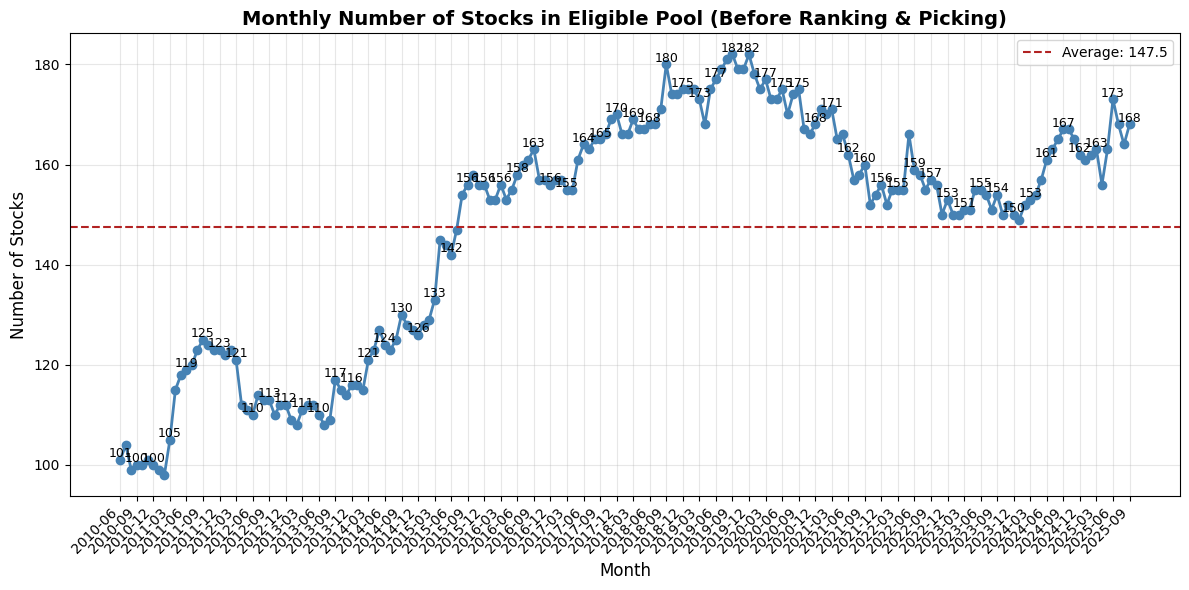

图表已保存为 'eligible_pool_trend.png'


<Figure size 640x480 with 0 Axes>

In [3]:
# 绘制每月合格池股票数量的变化
import matplotlib.pyplot as plt
import numpy as np

# 获取数据并确保月份为字符串格式
months = [str(month) for month in pool_sizes_record.keys()]
counts = list(pool_sizes_record.values())

# 创建图表
plt.figure(figsize=(12, 6))
plt.plot(months, counts, marker='o', linestyle='-', linewidth=2, color='steelblue')
plt.title('Monthly Number of Stocks in Eligible Pool (Before Ranking & Picking)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Stocks', fontsize=12)

# 设置x轴刻度：每隔3个月显示一次标签
plt.xticks(range(0, len(months), 3), 
           [months[i] for i in range(0, len(months), 3)], 
           rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 添加平均线
avg_count = np.mean(counts) if counts else 0
plt.axhline(y=avg_count, color='firebrick', linestyle='--', linewidth=1.5, 
           label=f'Average: {avg_count:.1f}')

# 添加数据点标签
for i, (month, count) in enumerate(zip(months, counts)):
    if i % 3 == 0 or i == len(months)-1:  # 每隔3个月或最后一个月显示标签
        plt.text(i, count+0.5, str(count), ha='center', fontsize=9)

plt.legend()
plt.show()

# 保存图表
plt.savefig('eligible_pool_trend.png', dpi=300, bbox_inches='tight')
print("图表已保存为 'eligible_pool_trend.png'")

Running Backtest...
Backtest finished. (Rebalance every 3 month(s), 165 periods)


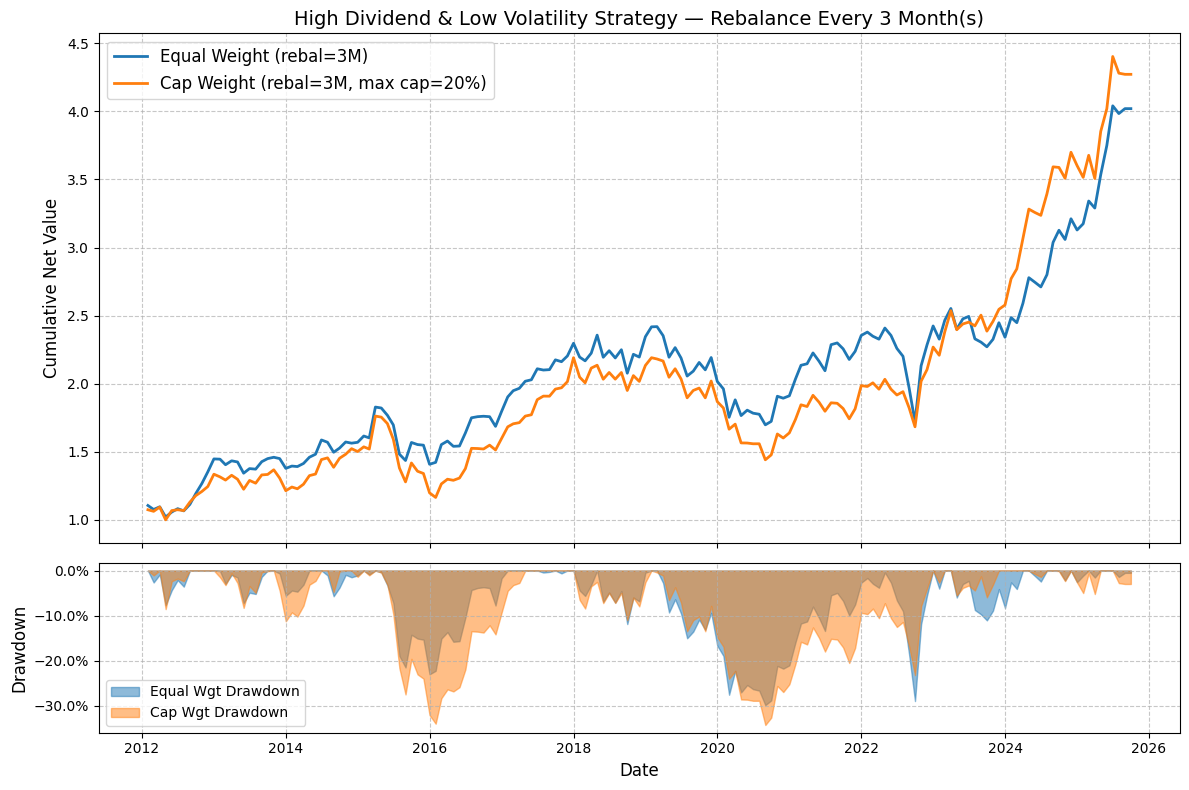


--- Performance Metrics ---
Metric               | Equal Weight    | Cap Weight     
-------------------------------------------------------
Annualized Return    | 11.62%        | 12.08%
Annualized Vol       | 17.26%        | 17.33%
Sharpe Ratio         | 0.67             | 0.70
Max Drawdown         | -29.81%        | -34.22%


In [4]:
# --- 运行回测 ---
print("Running Backtest...")

# ========== 参数设置 ==========
BACKTEST_START   = pd.Period('2012-01', 'M')
REBALANCE_FREQ   = 3   # 调仓频率（月），可选 1~12；1=每月调仓，3=季度，6=半年，12=年度
MAX_WEIGHT_LIMIT = 0.2 # 市值加权的单一个股权重上限，例如 0.15 表示最高15%
# ==============================

dates = signals.index[signals.index >= BACKTEST_START]

portfolio_ret_eq = []
portfolio_ret_cw = []
valid_dates = []

current_stocks = []   # 当前持仓（两种权重共用同一股票池）
rebalance_count = 0   # 已触发调仓次数，用于判断是否到调仓月

for t_idx, date_m in enumerate(dates):
    if date_m not in monthly_ret.index:
        continue

    # 判断是否调仓月（首月强制调仓）
    if t_idx % REBALANCE_FREQ == 0:
        new_stocks = signals.loc[date_m]
        if len(new_stocks) > 0:
            current_stocks = new_stocks

    if len(current_stocks) == 0:
        continue

    # 获取下月收益率序列
    nxt_ret = monthly_ret.loc[date_m].reindex(current_stocks).fillna(0)

    # 1. 等权配置 (Equal Weight)
    eq_weights = np.ones(len(current_stocks)) / len(current_stocks)
    ret_eq = np.sum(eq_weights * nxt_ret.values)

    # 2. 市值加权 (Cap Weight) — 使用当月市值动态计算权重
    if date_m in mcap_pivot.index:
        mcap_vals = mcap_pivot.loc[date_m].reindex(current_stocks).fillna(0)
        total_mcap = mcap_vals.sum()
        if total_mcap > 0:
            cw_weights = mcap_vals / total_mcap
            
            # 权重上限控制
            if MAX_WEIGHT_LIMIT is not None and MAX_WEIGHT_LIMIT < 1.0:
                # 循环分配多余的权重
                while (cw_weights > MAX_WEIGHT_LIMIT + 1e-6).any():
                    # 超过上限的设为上限
                    cw_weights[cw_weights > MAX_WEIGHT_LIMIT] = MAX_WEIGHT_LIMIT
                    
                    # 重新分配剩余权重给未超限的股票
                    mask = cw_weights < MAX_WEIGHT_LIMIT
                    if not mask.any():
                        break # 所有股票都达到上限（极端情况，比如选股太少）
                    remaining_weight = 1.0 - cw_weights[~mask].sum()
                    
                    if remaining_weight <= 0:
                        break
                        
                    cw_weights[mask] = cw_weights[mask] / cw_weights[mask].sum() * remaining_weight

            ret_cw = np.sum(cw_weights.values * nxt_ret.values)
        else:
            ret_cw = ret_eq
    else:
        ret_cw = ret_eq

    portfolio_ret_eq.append(ret_eq)
    portfolio_ret_cw.append(ret_cw)
    valid_dates.append(date_m)

# 转换为DataFrame
df_bt = pd.DataFrame({
    'date': valid_dates,
    'Equal_Weight_Returns': portfolio_ret_eq,
    'Cap_Weight_Returns': portfolio_ret_cw
})
# 设置索引：date_m 时点配仓，收益发生在 date_m + 1 个月
df_bt['date_return'] = df_bt['date'].apply(lambda x: x + 1)
df_bt.set_index('date_return', inplace=True)

# 计算净值曲线
df_bt['Equal_Weight_NetValue'] = (1 + df_bt['Equal_Weight_Returns']).cumprod()
df_bt['Cap_Weight_NetValue']   = (1 + df_bt['Cap_Weight_Returns']).cumprod()

print(f"Backtest finished. (Rebalance every {REBALANCE_FREQ} month(s), {len(df_bt)} periods)")

# --- 绘制收益曲线与回撤 ---
index_dates = df_bt.index.to_timestamp()

# 计算动态回撤（以初始净值1.0为峰值基准）
eq_dd = df_bt['Equal_Weight_NetValue'] / df_bt['Equal_Weight_NetValue'].cummax().clip(lower=1.0) - 1
cw_dd = df_bt['Cap_Weight_NetValue']   / df_bt['Cap_Weight_NetValue'].cummax().clip(lower=1.0)   - 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

ax1.plot(index_dates, df_bt['Equal_Weight_NetValue'], label=f'Equal Weight (rebal={REBALANCE_FREQ}M)', linewidth=2)
ax1.plot(index_dates, df_bt['Cap_Weight_NetValue'],   label=f'Cap Weight (rebal={REBALANCE_FREQ}M, max cap={MAX_WEIGHT_LIMIT*100:.0f}%)',   linewidth=2)
ax1.set_title(f'High Dividend & Low Volatility Strategy — Rebalance Every {REBALANCE_FREQ} Month(s)', fontsize=14)
ax1.set_ylabel('Cumulative Net Value', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(fontsize=12, loc='upper left')

import matplotlib.ticker as mtick
ax2.fill_between(index_dates, eq_dd, 0, alpha=0.5, label='Equal Wgt Drawdown', color='tab:blue')
ax2.fill_between(index_dates, cw_dd, 0, alpha=0.5, label='Cap Wgt Drawdown',   color='tab:orange')
ax2.set_ylabel('Drawdown', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(fontsize=10, loc='lower left')

plt.tight_layout()
plt.show()

# 打印绩效指标
def calc_metrics(returns):
    ann_ret = returns.mean() * 12
    ann_vol = returns.std() * np.sqrt(12)
    sharpe  = ann_ret / ann_vol if ann_vol != 0 else np.nan
    cum_ret = (1 + returns).cumprod()
    max_dd  = (cum_ret / cum_ret.cummax().clip(lower=1.0) - 1).min()
    return ann_ret, ann_vol, sharpe, max_dd

eq_ann_ret, eq_ann_vol, eq_sharpe, eq_mdd = calc_metrics(df_bt['Equal_Weight_Returns'])
cw_ann_ret, cw_ann_vol, cw_sharpe, cw_mdd = calc_metrics(df_bt['Cap_Weight_Returns'])

print("\n--- Performance Metrics ---")
print(f"{'Metric':<20} | {'Equal Weight':<15} | {'Cap Weight':<15}")
print("-" * 55)
print(f"{'Annualized Return':<20} | {eq_ann_ret:.2%} {'':<6} | {cw_ann_ret:.2%}")
print(f"{'Annualized Vol':<20} | {eq_ann_vol:.2%} {'':<6} | {cw_ann_vol:.2%}")
print(f"{'Sharpe Ratio':<20} | {eq_sharpe:.2f} {'':<11} | {cw_sharpe:.2f}")
print(f"{'Max Drawdown':<20} | {eq_mdd:.2%} {'':<6} | {cw_mdd:.2%}")

In [5]:
import statsmodels.api as sm

# 读取Fama-French三因子数据
ff3 = pd.read_csv('data/hk_ff3_factors.csv')
ff3['date_m'] = pd.to_datetime(ff3['date_m']).dt.to_period('M')
ff3.set_index('date_m', inplace=True)

# 准备回归的因变量和自变量 (使用市值加权组合收益)
# 对齐时间索引
common_dates = df_bt.index.intersection(ff3.index)
y = df_bt.loc[common_dates, 'Cap_Weight_Returns']
X = ff3.loc[common_dates, ['MKT', 'SMB', 'HML']]

# 添加常数项作为alpha
X = sm.add_constant(X)

# 运行OLS回归
model = sm.OLS(y, X).fit()

# 打印回归结果摘要
print(model.summary())

# 提取并打印Alpha及其显著性
alpha = model.params['const']
p_value = model.pvalues['const']

print("\n--- FF3 Regression Results ---")
print(f"Alpha (monthly): {alpha:.4%}")
print(f"Alpha t-stat:    {model.tvalues['const']:.4f}")
print(f"Alpha p-value:   {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Alpha IS statistically significant at 5% level.")
else:
    print("Conclusion: Alpha is NOT statistically significant at 5% level.")

                            OLS Regression Results                            
Dep. Variable:     Cap_Weight_Returns   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     199.3
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           8.24e-54
Time:                        14:01:15   Log-Likelihood:                 386.05
No. Observations:                 164   AIC:                            -764.1
Df Residuals:                     160   BIC:                            -751.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0079      0.002      4.320      0.0

In [6]:
# 以当前最新月份为例
current_m = signals.index.max()

# 1) HSCI 股票池数量
hsci_count = hsci.loc[hsci['date_m'] == current_m, 'sid'].nunique()
print(f"{current_m} HSCI 股票池数量: {hsci_count}")

# 1.1) HSCI 股票池平均数量（按月 unique sid，再取均值）
hsci_monthly_counts = (
    hsci.loc[hsci['date_m'].isin(signals.index)]
    .groupby('date_m')['sid']
    .nunique()
)

hsci_avg_count = hsci_monthly_counts.mean()
print(f"HSCI 股票池平均数量({signals.index.min()}~{signals.index.max()}): {hsci_avg_count:.2f}")
# 2) 成交量（这里用 adtv_3m）10分位数
adtv_cur = df_factors.loc[
    (df_factors['date_m'] == current_m) & (df_factors['is_hsci'] == 1),
    'adtv_3m'
].dropna()

deciles = adtv_cur.quantile(np.arange(0.1, 1.0, 0.1))
deciles.index = [f"P{int(q*100)}" for q in deciles.index]

print(f"\n{current_m} HSCI 股票池 adtv_3m 分位数:")
print(deciles.to_string(float_format=lambda x: f"{x:,.2f}"))

2025-09 HSCI 股票池数量: 526
HSCI 股票池平均数量(2010-06~2025-09): 458.81

2025-09 HSCI 股票池 adtv_3m 分位数:
P10    26,571,266.40
P20    40,861,193.87
P30    61,378,033.19
P40    87,034,182.28
P50   109,910,708.11
P60   169,330,529.90
P70   242,170,042.91
P80   381,111,719.14
P90   724,099,391.88


In [7]:
# Check filter drop-offs for 2025-09
test_m = pd.Period('2025-09', 'M')
if test_m in df_factors['date_m'].values:
    group = df_factors[df_factors['date_m'] == test_m]
    print(f"Initial stocks in group (after inner joins): {len(group)}")
    
    current_m = group['date_m'].iloc[0]
    end_date = current_m.to_timestamp(how='end')
    dy_36m = dy_pivot.loc[:end_date].tail(36)
    
    valid_sid = dy_36m.columns[(dy_36m.notna().all()) & (dy_36m.gt(0).all())]
    pool1 = group[group['sid'].isin(valid_sid)]
    print(f"After '36 months DY > 0' filter: {len(pool1)}")
    
    adtv_threshold = group['adtv_3m'].quantile(0.3)
    mcap_threshold = group['mcap'].quantile(0.3)
    
    pool2 = pool1[(pool1['adtv_3m'] >= adtv_threshold) & (pool1['mcap'] >= mcap_threshold)]
    print(f"After 'ADTV >= Top 70% ({adtv_threshold:.2f}) & MCAP >= Top 70% ({mcap_threshold:.2f})' filter: {len(pool2)}")


Initial stocks in group (after inner joins): 343
After '36 months DY > 0' filter: 243
After 'ADTV >= Top 70% (61378033.19) & MCAP >= Top 70% (19777798404.89)' filter: 146


In [8]:
# === 单纯的红利因子(3-Year Avg DPS / Current Price)五分组与多空策略验证 ===
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats

print("Grouping by Pure Dividend Yield Factor with Q0...")

portfolio_returns_q = []
portfolio_counts_q = []

for date_m, group in df_factors.groupby('date_m'):
    if date_m not in monthly_ret.index:
        continue
        
    current_m = group['date_m'].iloc[0]
    end_date = current_m.to_timestamp(how='end')
    
    # 1. 先进行整体的流动性与市值过滤 (Top 70%)
    if len(group) > 0:
        adtv_threshold = group['adtv_3m'].quantile(0.2)
        mcap_threshold = group['mcap'].quantile(0.2)
        valid_pool = group[(group['adtv_3m'] >= adtv_threshold) & (group['mcap'] >= mcap_threshold)].copy()
    else:
        continue
        
    if len(valid_pool) < 10: # 样本太少不足以稳定分组
        continue

    # 提取并验证过去36个月股息是否都不为空且大于0
    dy_36m_local = dy_pivot.loc[:end_date].tail(36)
    valid_sid = dy_36m_local.columns[(dy_36m_local.notna().all()) & (dy_36m_local.gt(0).all())]
    
    # 2. 划分为“无稳定分红组(Q0)”和“有稳定分红组(待分Q1-Q5)”
    pool_pos = valid_pool[valid_pool['sid'].isin(valid_sid)].copy()
    pool_zero = valid_pool[~valid_pool['sid'].isin(valid_sid)].copy()
    
    # Q0 直接赋值
    pool_zero['quintile'] = 'Q0'

    if len(pool_pos) < 5: 
        continue
        
    # 计算用于排序的核心股息指标评分: 3年平均股息分数 (3-Year Avg DPS / Current Price)
    price_36m_local = price_pivot.reindex(dy_36m_local.index, method='ffill')
    dps_36m_local = price_36m_local * dy_36m_local
    current_prices_local = price_36m_local.iloc[-1]
    
    avg_dps = dps_36m_local.mean()
    score_series = avg_dps / current_prices_local
        
    pool_pos['score'] = pool_pos['sid'].map(score_series)
    pool_pos = pool_pos.dropna(subset=['score'])
    
    if len(pool_pos) < 5:
        continue
        
    # MAD 结合分位数剔除前后 5% 的极值
    lower_cutoff = pool_pos['score'].quantile(0.05)
    upper_cutoff = pool_pos['score'].quantile(0.95)
    pool_pos = pool_pos[(pool_pos['score'] >= lower_cutoff) & (pool_pos['score'] <= upper_cutoff)]

    if len(pool_pos) < 5:
        continue
        
    # 按红利因子(score)均分为5组 (Q1 最低, Q5 最高)
    try:
        pool_pos['quintile'] = pd.qcut(pool_pos['score'].rank(method='first'), 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    except ValueError:
        continue
    
    # 合并有分红和无分红的池子
    combined_pool = pd.concat([pool_zero, pool_pos])
    
    # 计算下个月各分组的等权收益率
    nxt_ret = monthly_ret.loc[date_m].replace([np.inf, -np.inf], np.nan)
    
    ret_dict = {'date_return': date_m + 1}
    count_dict = {'date_return': date_m + 1}
    
    for q in ['Q0', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5']:
        sids = combined_pool[combined_pool['quintile'] == q]['sid']
        count_dict[q] = len(sids)
        if len(sids) > 0:
            group_ret = nxt_ret.reindex(sids).fillna(0).mean() # 等权计算
        else:
            group_ret = 0.0
        ret_dict[q] = group_ret
        
    portfolio_returns_q.append(ret_dict)
    portfolio_counts_q.append(count_dict)

# 组合收益DataFrame
df_q_ret = pd.DataFrame(portfolio_returns_q).set_index('date_return')
df_q_count = pd.DataFrame(portfolio_counts_q).set_index('date_return')

# 增加多空收益组合 (多头 Q5: 红利最高)
df_q_ret['L-S (Q5-Q1)'] = df_q_ret['Q5'] - df_q_ret['Q1']
df_q_ret['L-S (Q5-Q0)'] = df_q_ret['Q5'] - df_q_ret['Q0']

df_q_count['L-S (Q5-Q1)'] = df_q_count['Q5'] + df_q_count['Q1']
df_q_count['L-S (Q5-Q0)'] = df_q_count['Q5'] + df_q_count['Q0']

# 替换可能出现的无限值并处理缺失值
df_q_ret = df_q_ret.replace([np.inf, -np.inf], np.nan).fillna(0)

# --- 1. 打印月度收益及T值表格 (Newey-West HAC 调整) ---
mean_count = df_q_count.mean()

avg_ret_list = []
t_stats_nw_list = []
p_vals_nw_list = []

for q in df_q_ret.columns:
    y_q = df_q_ret[q].dropna() * 100
    X_const = np.ones(len(y_q)) # 只对常数进行回归
    
    # 采用带有3阶滞后的 Newey-West 标准误
    nw_model = sm.OLS(y_q, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    
    avg_ret_list.append(nw_model.params[0])
    t_stats_nw_list.append(nw_model.tvalues[0])
    p_vals_nw_list.append(nw_model.pvalues[0])

# 计算显著性星号
star_list = []
for p in p_vals_nw_list:
    if p < 0.01:
        star_list.append('***')
    elif p < 0.05:
        star_list.append('**')
    elif p < 0.1:
        star_list.append('*')
    else:
        star_list.append('')

df_summary = pd.DataFrame({
    'Avg Monthly Ret (%)': [f"{m:.3f} {s}" for m, s in zip(avg_ret_list, star_list)],
    'T-stat (NW)': np.round(t_stats_nw_list, 3),
    'p-value (NW)': np.round(p_vals_nw_list, 4),
    'n (months)': len(df_q_ret),
    'n_stock (avg)': mean_count.round(1)
}, index=df_q_ret.columns)

print("\n=== Monthly Return Summary (Equal Weight) ===")
print("Significance levels: * p<0.1, ** p<0.05, *** p<0.01 (Newey-West HAC t-stats)")
print("Q0: Non-stable Dividend | Q1 (Lowest Dividend Yield) -> Q5 (Highest Dividend Yield)")
print(df_summary)

# --- 2. FF3 Alpha 计算 (Newey-West HAC 调整) ---
# 使用香港本地三因子数据
ff3 = pd.read_csv('data/hk_ff3_factors.csv')
ff3['date_m'] = pd.to_datetime(ff3['date_m']).dt.to_period('M')
ff3.set_index('date_m', inplace=True)

# 时间对齐
common_dates = df_q_ret.index.intersection(ff3.index)

alpha_rows = []
for port in ['Q0', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'L-S (Q5-Q1)', 'L-S (Q5-Q0)']:
    y_alpha = df_q_ret.loc[common_dates, port]
    X_alpha = ff3.loc[common_dates, ['MKT', 'SMB', 'HML']]
    X_alpha = sm.add_constant(X_alpha)
    
    # 稳健性检验 (OLS with HAC)
    # 计算 alpha 时同样采用 3阶滞后的 Newey-West 标准误
    model_alpha = sm.OLS(y_alpha, X_alpha).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    
    alpha_val = model_alpha.params['const'] * 100 # 转换为 %
    p_val_a = model_alpha.pvalues['const']
    t_val_a = model_alpha.tvalues['const']
    
    # 添加显著性星号
    stars_a = ''
    if p_val_a < 0.01:
        stars_a = '***'
    elif p_val_a < 0.05:
        stars_a = '**'
    elif p_val_a < 0.1:
        stars_a = '*'
        
    alpha_rows.append({
        'Portfolio': port,
        'Alpha (Monthly %)': f"{alpha_val:.3f} {stars_a}",
        'Alpha t-stat (NW)': round(t_val_a, 2),
        'p-value (NW)': round(p_val_a, 4),
        'n (months)': len(y_alpha),
        'n_stock (avg)': round(mean_count[port], 1)
    })

df_alpha = pd.DataFrame(alpha_rows).set_index('Portfolio')

print("\n=== Fama-French 3-Factor Alpha Table ===")
print("Significance levels: * p<0.1, ** p<0.05, *** p<0.01 (Newey-West HAC t-stats)\n")
print(df_alpha)

Grouping by Pure Dividend Yield Factor with Q0...

=== Monthly Return Summary (Equal Weight) ===
Significance levels: * p<0.1, ** p<0.05, *** p<0.01 (Newey-West HAC t-stats)
Q0: Non-stable Dividend | Q1 (Lowest Dividend Yield) -> Q5 (Highest Dividend Yield)
            Avg Monthly Ret (%)  T-stat (NW)  p-value (NW)  n (months)  \
Q0                       0.682         1.434        0.1515         184   
Q1                       0.683         1.464        0.1431         184   
Q2                       0.493         1.121        0.2623         184   
Q3                       0.635         1.595        0.1108         184   
Q4                      0.698 *        1.801        0.0717         184   
Q5                     0.990 **        2.331        0.0198         184   
L-S (Q5-Q1)              0.307         1.272        0.2033         184   
L-S (Q5-Q0)              0.308         1.435        0.1512         184   

             n_stock (avg)  
Q0                    87.8  
Q1               